# Physical gradient training: optimizer comparison at matched evaluation budget

## Statement of the problem
Gradients with respect to the squeezing controls are obtained by repeating the reservoir experiment at nearby settings, $\partial\mathcal L/\partial\vartheta_i\approx[\mathcal L(\vartheta+h e_i)-\mathcal L(\vartheta-h e_i)]/2h$, followed by projected gradient descent with backtracking. Is this more efficient than derivative-free search when **every** reservoir evaluation (probes and rejected steps included) is counted?

**Protocol.** 12 random initial settings, 100 reservoir evaluations each, three methods: finite-difference gradient descent ($h=10^{-2}$), Nelder–Mead (bounded), uniform random search. Best-so-far training loss recorded after every evaluation.

This comparison is not the point of the paper (it lives in Supplementary Note 7): in three controls the 5 %-basin is broad and any method finds it; the gradient only refines better.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


## Compute
`run_fig3.py mg` (~35 min).

In [2]:
if RUN: subprocess.run(['python3', 'run_fig3.py', 'mg'])
f3 = ld('fig3_mg.npz'); sc = ld('fig2_scans.npz'); L0 = sc['L3'][0, 0, 0]
Lstar = min(sc['L3'].min(), sc['L1'].min(), sc['L2'].min(), *[f3[f'final_{k}'][:, 3].min() for k in ('gd', 'nm', 'rs')])
for k, name in (('gd', 'gradient descent'), ('nm', 'Nelder-Mead'), ('rs', 'random search')):
    C = f3[f'curve_{k}']; reach5 = [(np.argmax(c <= 1.05 * Lstar) + 1) if np.any(c <= 1.05 * Lstar) else np.inf for c in C]
    print('%-16s median reduction %.0f%%; within 5%% of L* after median %s evals; within 1%% in %d/%d runs; median final %.3e' % (name, 100 * np.median(1 - C[:, -1] / C[:, 0]), np.median(reach5), np.sum(C[:, -1] <= 1.01 * Lstar), len(C), np.median(C[:, -1])))

gradient descent median reduction 23%; within 5% of L* after median 15.0 evals; within 1% in 6/12 runs; median final 4.706e-03
Nelder-Mead      median reduction 23%; within 5% of L* after median 6.0 evals; within 1% in 5/12 runs; median final 4.739e-03
random search    median reduction 25%; within 5% of L* after median 7.5 evals; within 1% in 5/12 runs; median final 4.689e-03


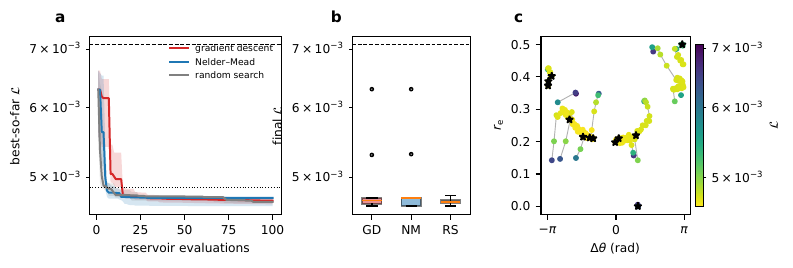

In [3]:
make_figs.fig3('mg', 'fig3_optim.pdf', L0, Lstar); show('paper/figs/fig3_optim.pdf')

**Supplementary Figure 5.** (a) Median best-so-far loss; (b) final-loss distributions; (c) accepted gradient-descent paths in the $(r_e,\Delta\theta)$ plane. Two runs of each local method are trapped at boundary minima of the $r$ channel; two converge to a secondary basin near $\Delta\theta\approx\pi$.